# Lista de Exercícios — MQE, MQE de Teste e Variância

**Disciplina:** Introdução à Estatística Computacional
**Curso:** Sistemas de Informação — UESB / DCT
**Professor:** Guilherme Waldschmidt Pereira

---

A ideia da lista é a mesma do começo ao fim: ajustar uma regressão, medir o erro
no conjunto de treino e no de teste, e olhar o que acontece com esses dois números
quando eu mudo a flexibilidade do modelo ou a variabilidade dos dados. As contas
estão todas no notebook; as respostas escritas vêm logo depois de cada bloco de código,
usando os valores que o código realmente produziu.

Onde a lista pede para "calcular o MQE", uso a fórmula
$MQE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$, que é exatamente o que o
`mean_squared_error` do scikit-learn devolve.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

## Parte I — Cálculo e interpretação do MQE

Base original: horas de estudo de 1 a 10 e a nota correspondente.
Divido em 70% treino / 30% teste com `random_state=1` (o mesmo seed do exemplo da Parte V),
ajusto a regressão linear simples e calculo os dois erros.

In [2]:
dados = pd.DataFrame({
    "horas_estudo": list(range(1, 11)),
    "nota": [50, 55, 58, 65, 69, 74, 78, 83, 87, 92]
})

X = dados[["horas_estudo"]]
y = dados["nota"]

# Q1 - separa 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print("Treino (horas):", sorted(X_train["horas_estudo"].tolist()))
print("Teste  (horas):", sorted(X_test["horas_estudo"].tolist()))

# Q2 - ajusta a regressão linear
modelo = LinearRegression().fit(X_train, y_train)
print(f"\nReta ajustada:  nota = {modelo.intercept_:.4f} + {modelo.coef_[0]:.4f} * horas")

# Q3 e Q4 - MQE de treino e de teste
mqe_treino = mean_squared_error(y_train, modelo.predict(X_train))
mqe_teste  = mean_squared_error(y_test,  modelo.predict(X_test))
print(f"\nMQE treino = {mqe_treino:.4f}")
print(f"MQE teste  = {mqe_teste:.4f}")

Treino (horas): [1, 2, 4, 5, 6, 8, 9]
Teste  (horas): [3, 7, 10]

Reta ajustada:  nota = 45.8269 + 4.6346 * horas

MQE treino = 0.1511
MQE teste  = 1.0327


In [3]:
# Conferindo o MQE de teste na mão, ponto a ponto
det = X_test.copy()
det["nota_real"] = y_test
det["nota_prevista"] = modelo.predict(X_test)
det["residuo"] = det["nota_real"] - det["nota_prevista"]
det["residuo2"] = det["residuo"]**2
print(det.to_string(index=False))
print(f"\nsoma dos resíduos² = {det['residuo2'].sum():.4f}  ->  / 3 = {det['residuo2'].mean():.4f}")

 horas_estudo  nota_real  nota_prevista  residuo  residuo2
            3         58        59.7308  -1.7308    2.9956
           10         92        92.1731  -0.1731    0.0300
            7         78        78.2692  -0.2692    0.0725

soma dos resíduos² = 3.0980  ->  / 3 = 1.0327


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


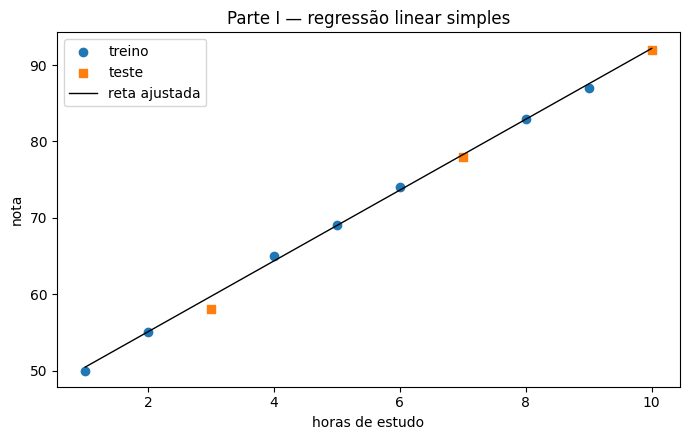

In [4]:
plt.figure(figsize=(7,4.5))
plt.scatter(X_train, y_train, label="treino")
plt.scatter(X_test, y_test, marker="s", label="teste")
xx = np.linspace(1, 10, 100).reshape(-1, 1)
plt.plot(xx, modelo.predict(xx), color="k", lw=1, label="reta ajustada")
plt.xlabel("horas de estudo"); plt.ylabel("nota")
plt.title("Parte I — regressão linear simples")
plt.legend(); plt.tight_layout(); plt.show()

**Respostas da Parte I**

**Q5 — O modelo teve desempenho parecido nos dois conjuntos?**
O MQE de treino ficou em **0,1511** e o de teste em **1,0327**. Em valor absoluto o erro
de teste é cerca de 7 vezes maior, mas os dois são pequenos perto da escala das notas
(que vão de 50 a 92). Tirando a raiz, o erro típico no teste é de mais ou menos 1 ponto
na nota. Então, na prática, o desempenho é parecido sim — a diferença existe mas é pequena.

**Q6 — O modelo generaliza bem?**
Generaliza. Um erro de teste de pouco mais de 1 (em nota²) significa que, em dados que o
modelo não viu no ajuste, ele erra a nota em torno de 1 ponto. Como a relação entre horas
e nota é quase uma reta perfeita, a regressão linear consegue prever bem fora do treino.

**Q7 — Sobre os dados:**

(a) Sim, a relação é claramente crescente: quanto mais horas, maior a nota.

(b) Sim, é aproximadamente linear. Os pontos sobem de forma quase constante (uns 4 a 5
pontos de nota por hora a mais de estudo).

(c) Nenhum ponto foge muito do padrão. O que mais "puxa" é a hora 3 (nota 58), que ficou
um pouco abaixo da reta (resíduo de cerca de −1,73), mas nada que dê pra chamar de outlier.

(d) Sim, o modelo linear é adequado. O erro de treino é quase zero e a reta acompanha bem
o conjunto inteiro.

## Parte II — Modelo mais flexível (polinômio de grau 2)

Mesmo conjunto da Parte I, mesma divisão (`random_state=1`), agora ajustando
$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon$.

In [5]:
poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(X_train, y_train)

mqe_treino_poly = mean_squared_error(y_train, poly.predict(X_train))
mqe_teste_poly  = mean_squared_error(y_test,  poly.predict(X_test))

lr = poly.named_steps["linearregression"]
print(f"nota = {lr.intercept_:.4f} + {lr.coef_[1]:.4f}*x + {lr.coef_[2]:.4f}*x^2\n")

comp = pd.DataFrame({
    "modelo": ["Linear simples", "Polinomial grau 2"],
    "MQE_treino": [mqe_treino, mqe_treino_poly],
    "MQE_teste":  [mqe_teste,  mqe_teste_poly],
})
print(comp.to_string(index=False))

nota = 44.9172 + 5.1524*x + -0.0518*x^2

           modelo  MQE_treino  MQE_teste
   Linear simples      0.1511     1.0327
Polinomial grau 2      0.0402     1.4613


**Respostas da Parte II**

**Q8 —** Para o polinômio de grau 2: MQE de treino = **0,0402** e MQE de teste = **1,4613**.

**Q9 — Comparação entre os dois modelos.**
No treino o polinômio é melhor (0,0402 contra 0,1511 da reta). No teste ele é pior
(1,4613 contra 1,0327). Ou seja, o modelo mais flexível decorou um pouco melhor os pontos
de treino, mas previu pior nos pontos novos.

**Q10 — Menor MQE de treino:** o polinomial de grau 2.

**Q11 — Menor MQE de teste:** o linear simples.

**Q12 — O menor MQE de treino é necessariamente o melhor modelo para previsão?**
Não. Quem teve o menor erro de treino foi o polinômio, mas quem previu melhor nos dados de
teste foi a reta. Como o que interessa é acertar em dados novos, aqui o modelo linear é a
escolha melhor. Isso é um caso pequeno de overfitting: o grau 2 se ajustou a detalhes do
treino que não ajudam (e até atrapalham) na previsão.

**Q13 — Por que mais flexibilidade reduz o erro de treino mas não o de teste?**
Um modelo mais flexível tem mais "liberdade" pra curvar a função e passar perto dos pontos
de treino — por isso o erro de treino quase sempre cai. Só que parte dessa curvatura está
seguindo o ruído daquela amostra específica, e não a relação verdadeira. Quando chegam
pontos novos, que têm outro ruído, essas curvas extras não ajudam e o erro de teste pode
ficar igual ou pior.

## Parte III — Dados com alta variância

Base de 20 pontos em que, para a mesma faixa de horas, as notas oscilam bastante.
Faço a divisão treino/teste e ajusto a regressão linear para cada um dos seeds pedidos.

In [6]:
alta = pd.DataFrame({
    "horas_estudo": list(range(1, 21)),
    "nota": [45, 70, 52, 80, 60, 88, 66, 95, 73, 100,
             75, 98, 82, 105, 85, 110, 90, 115, 95, 120]
})

Xa = alta[["horas_estudo"]]
ya = alta["nota"]

seeds = [1, 5, 10, 20, 30, 50, 100]

def roda_seeds(X, y, seeds):
    linhas = []
    for s in seeds:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=s)
        m = LinearRegression().fit(Xtr, ytr)
        linhas.append({
            "seed": s,
            "MQE_treino": mean_squared_error(ytr, m.predict(Xtr)),
            "MQE_teste":  mean_squared_error(yte, m.predict(Xte)),
        })
    return pd.DataFrame(linhas)

tab_alta = roda_seeds(Xa, ya, seeds)   # Q14 a Q18
print(tab_alta.to_string(index=False))

 seed  MQE_treino  MQE_teste
    1    124.3143   213.9133
    5    145.9329   134.6981
   10    108.3963   252.6789
   20    139.3197   163.2188
   30    133.7850   164.6390
   50    135.5820   159.4304
  100    151.8833   133.9976


**Respostas da Parte III**

A tabela acima é a pedida na questão 18.

**Q19 — Os MQE de teste ficaram próximos ou variaram bastante?**
Variaram muito. Foram de cerca de **134** (seed 100) até **253** (seed 10). Não dá pra
confiar num único valor.

**Q20 — O que essa variação indica?**
Indica que o resultado depende fortemente de qual amostra caiu no treino e qual caiu no
teste. Trocando só o seed, a reta muda e o erro de teste muda junto. O modelo é instável
em relação à amostra de treinamento.

**Q21 — Por que dados com alta variância deixam a avaliação instável?**
Porque com muito ruído cada divisão pega pontos diferentes "puxando" a reta pra lados
diferentes. Como há bastante dispersão em torno da tendência, o erro medido depende de
quais pontos sortudos/azarados foram parar no teste — e isso muda muito de uma divisão pra
outra.

**Q22 — Em alguma repetição o MQE de teste ficou muito maior que o de treino?**
Sim, em várias. No seed 1 foi 213,9 no teste contra 124,3 no treino; no seed 10 foi
252,7 contra 108,4. Isso indica que naquelas divisões o teste calhou de pegar pontos mais
difíceis de prever, e que o modelo não está generalizando de forma estável nessa base
barulhenta.

## Parte IV — Dados com baixa variância

Agora a mesma rotina, mas numa base de 20 pontos quase em cima de uma reta (pouco ruído).

In [7]:
baixa = pd.DataFrame({
    "horas_estudo": list(range(1, 21)),
    "nota": [51, 54, 57, 61, 64, 67, 70, 74, 77, 80,
             83, 86, 89, 92, 95, 98, 101, 104, 107, 110]
})

Xb = baixa[["horas_estudo"]]
yb = baixa["nota"]

tab_baixa = roda_seeds(Xb, yb, seeds)
print(tab_baixa.to_string(index=False))

 seed  MQE_treino  MQE_teste
    1      0.1860     0.1449
    5      0.1336     0.3328
   10      0.1628     0.2230
   20      0.1981     0.1155
   30      0.1920     0.1327
   50      0.1357     0.3315
  100      0.1694     0.3208


In [8]:
resumo = pd.DataFrame({
    "base": ["Alta variância", "Baixa variância"],
    "media_MQE_teste": [tab_alta.MQE_teste.mean(), tab_baixa.MQE_teste.mean()],
    "desvio_MQE_teste": [tab_alta.MQE_teste.std(ddof=1), tab_baixa.MQE_teste.std(ddof=1)],
    "media_MQE_treino": [tab_alta.MQE_treino.mean(), tab_baixa.MQE_treino.mean()],
})
print(resumo.to_string(index=False))
print(f"\nO desvio do MQE de teste da base de alta variância é "
      f"{resumo.desvio_MQE_teste[0]/resumo.desvio_MQE_teste[1]:.0f}x maior que o da base de baixa variância.")

           base  media_MQE_teste  desvio_MQE_teste  media_MQE_treino
 Alta variância         174.6537           43.4768          134.1734
Baixa variância           0.2287            0.0991            0.1682

O desvio do MQE de teste da base de alta variância é 439x maior que o da base de baixa variância.


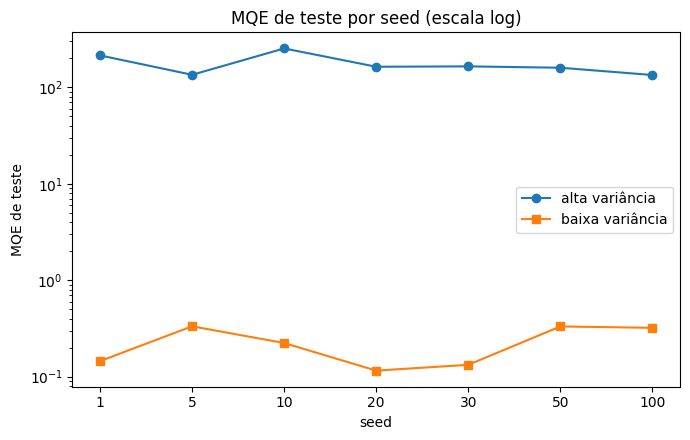

In [9]:
plt.figure(figsize=(7,4.5))
plt.plot(tab_alta.seed.astype(str), tab_alta.MQE_teste, marker="o", label="alta variância")
plt.plot(tab_baixa.seed.astype(str), tab_baixa.MQE_teste, marker="s", label="baixa variância")
plt.xlabel("seed"); plt.ylabel("MQE de teste")
plt.yscale("log")
plt.title("MQE de teste por seed (escala log)")
plt.legend(); plt.tight_layout(); plt.show()

**Respostas da Parte IV**

**Q25 — Comparação entre as duas bases.**
A diferença é gritante. Na base de alta variância o MQE de teste ficou na casa das centenas
(média ≈ 174,7); na de baixa variância ficou abaixo de 1 (média ≈ 0,23). E o mais
importante: na base de baixa variância os resultados quase não mudam de um seed pro outro.

**Q26 — Em qual base os MQE de teste foram mais estáveis?**
Na de baixa variância. O desvio-padrão do MQE de teste foi cerca de 0,10 ali, contra ~43,5
na de alta variância — uma diferença de mais de 400 vezes.

**Q27 — Em qual base houve maior diferença entre treino e teste?**
Na de alta variância. Em vários seeds o teste foi bem maior que o treino. Na base de baixa
variância treino e teste ficam praticamente colados (ambos em torno de 0,1 a 0,3).

**Q28 — A troca de seed teve mais impacto em qual base?**
Na de alta variância, e bem mais. Trocar o seed lá faz o erro pular de 134 pra 253; na base
de baixa variância trocar o seed mexe só na segunda/terceira casa decimal. Quanto mais
ruído nos dados, mais a escolha da amostra de treino influencia o resultado.

**Q29 — Relação entre variância dos dados, escolha da amostra e estabilidade do MQE de teste.**
Quando os dados têm pouca variância, qualquer amostra de treino representa bem a relação
verdadeira, então o MQE de teste fica parecido independente de qual fatia foi sorteada — é
estável. Quando a variância é alta, cada amostra "conta uma história" um pouco diferente,
a reta ajustada muda mais, e o MQE de teste fica pulando. Resumindo: mais variância nos
dados → mais dependência da amostra de treino → MQE de teste menos estável.

## Parte V — Implementação em Python

As questões 30 a 33 já estão atendidas pelas células acima: a função `roda_seeds`
adapta o experimento para qualquer base (alta ou baixa variância), tem a estrutura de
repetição variando o seed e devolve um `DataFrame` com as colunas `seed`, `MQE_treino` e
`MQE_teste`. Abaixo só consolido a média e o desvio-padrão do MQE de teste (Q34).

In [10]:
# Q34 - media e desvio do MQE de teste por base
estat = pd.DataFrame({
    "base": ["alta_variancia", "baixa_variancia"],
    "media_MQE_teste":  [tab_alta.MQE_teste.mean(),         tab_baixa.MQE_teste.mean()],
    "desvio_MQE_teste": [tab_alta.MQE_teste.std(ddof=1),    tab_baixa.MQE_teste.std(ddof=1)],
})
print(estat.to_string(index=False))

           base  media_MQE_teste  desvio_MQE_teste
 alta_variancia         174.6537           43.4768
baixa_variancia           0.2287            0.0991


**Q35 — Interpretação do desvio-padrão do MQE de teste.**
O desvio-padrão mede o quanto o erro de teste balança quando eu repito o experimento com
divisões diferentes. Desvio alto (como os ~43,5 da base de alta variância) quer dizer modelo
instável: o resultado que eu reporto depende de sorte na divisão. Desvio baixo (os ~0,10 da
base de baixa variância) quer dizer que o modelo é confiável — não importa muito como eu
corto os dados, o erro fica parecido.

**Q36 — Por que não avaliar um modelo com uma única divisão treino/teste?**
Porque, como ficou claro na Parte III, uma única divisão pode dar um número enganoso — bom
ou ruim só por causa do sorteio. Se eu tivesse olhado só o seed 100 da base de alta
variância, acharia o modelo ótimo (134); só o seed 10, acharia péssimo (253). Por isso o
certo é repetir várias divisões (ou usar validação cruzada) e olhar a média e o desvio, que
é o que esses experimentos fizeram.

## Parte VI — Questões conceituais

**Q37 — Diferença entre MQE de treino e MQE de teste.**
O MQE de treino é o erro medido nos mesmos dados usados pra ajustar o modelo. O MQE de teste
é o erro medido em dados separados, que o modelo não viu no ajuste. O de treino diz o quanto
o modelo "acertou o que já conhecia"; o de teste diz o quanto ele acerta de verdade em dados
novos, que é o que realmente importa.

**Q38 — Por que o MQE de treino costuma ser menor que o de teste?**
Porque o modelo foi ajustado justamente pra minimizar o erro nos dados de treino — ele teve
a chance de "se moldar" àqueles pontos. Nos dados de teste ele não teve essa vantagem, e
ainda enfrenta o ruído próprio desses pontos novos, então o erro tende a ser maior.

**Q39 — O que significa um modelo generalizar bem?**
Significa que ele acerta em dados novos quase tão bem quanto nos dados de treino — ou seja,
ele aprendeu a relação verdadeira e não só decorou a amostra. Na prática, é ter MQE de teste
baixo e próximo do MQE de treino.

**Q40 — O que é underfitting e como aparece nos MQE?**
Underfitting é quando o modelo é simples demais pra capturar o padrão dos dados (por exemplo,
ajustar uma reta numa relação bem curva). Aparece como MQE de treino alto **e** MQE de teste
alto: o modelo erra muito até nos próprios dados de treino, porque nem ali ele consegue se
ajustar.

**Q41 — O que é overfitting e como aparece nos MQE?**
Overfitting é quando o modelo é flexível demais e acaba decorando o ruído do treino. Aparece
como MQE de treino muito baixo, mas MQE de teste bem maior — uma folga grande entre os dois.
Foi mais ou menos o que aconteceu com o polinômio de grau 2 na Parte II, em escala pequena.

**Q42 — Relação entre flexibilidade do modelo e MQE de treino.**
Quanto mais flexível o modelo, menor tende a ser o MQE de treino. Mais parâmetros e mais
curvatura permitem passar cada vez mais perto dos pontos de treino, até o ponto de quase
zerar o erro ali.

**Q43 — Por que aumentar a flexibilidade pode piorar o MQE de teste?**
Porque a partir de certo ponto o modelo para de aprender a relação real e passa a se ajustar
ao ruído da amostra de treino. Esse "extra" não vale pra dados novos (que têm outro ruído),
então o erro de teste para de cair e volta a subir, mesmo com o erro de treino continuando a
diminuir.

**Q44 — Trade-off entre viés e variância.**
Viés é o erro de o modelo ser simples demais e não conseguir representar o padrão (caso do
underfitting). Variância é o erro de o modelo ser sensível demais à amostra específica de
treino, mudando muito de uma amostra pra outra (caso do overfitting). O problema é que
reduzir um costuma aumentar o outro: modelo muito simples tem viés alto e variância baixa;
modelo muito flexível tem viés baixo e variância alta. O bom modelo fica num meio-termo, com
o menor erro total em dados novos.

**Q45 — Eu escolheria o modelo com menor MQE de treino ou de teste?**
O de menor MQE de teste. O objetivo de um modelo é prever bem dados que ele ainda não viu, e
quem mede isso é o erro de teste. O erro de treino sozinho engana, porque um modelo que decora
tudo zera o treino e mesmo assim pode prever mal. Foi exatamente o caso da Parte II: o
polinômio teve o menor treino, mas a reta, com o menor teste, é a escolha melhor.